# HW 2



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
from matplotlib import pylab
params = {'xtick.labelsize': 18,
 'ytick.labelsize': 18,
 'axes.titlesize' : 22,
 'axes.labelsize' : 20,
 'legend.fontsize': 18,
 'legend.title_fontsize': 22,
 'figure.titlesize': 24 }
pylab.rcParams.update(params)

## Loading the dataset

In [3]:
!rm *.csv

from google.colab import files

print("Please load the raw csv train data")
uploadedData = files.upload()
filename = list(uploadedData)[0]

train_df = pd.read_csv(filename)

rm: cannot remove '*.csv': No such file or directory
Please load the raw csv train data


Saving train_df_prepared.csv to train_df_prepared.csv


In [4]:
print("Please load the raw csv test data")
uploadedData = files.upload()
filename = list(uploadedData)[0]

test_df = pd.read_csv(filename)

Please load the raw csv test data


Saving test_df_prepared.csv to test_df_prepared.csv


# Part 1

## Task - Create a temporary DataFrame containing PCR_01 and PCR_08

In [43]:
# Train set
train_pcr1_pcr8 = train_df[['PCR_01','PCR_08']]
train_spread = train_df['spread']

# Test set - will be used later

test_pcr1_pcr8 = test_df[['PCR_01','PCR_08']]
test_spread = test_df['spread']

In [44]:
def visualize_clf(clf, X, Y, title,
                  xlabel, ylabel,
                  marker_size=50,
                  grid_length=300,
                  linewidths=None):
    import matplotlib.pyplot as plt
    import pandas as pd
    from matplotlib.colors import ListedColormap

    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()

    # For internal use here, make sure labels are 0 and 1
    Y = np.ravel(Y).astype(int)
    labels = set(Y)
    assert len(labels) == 2, "Can only visualize two unique labels"

    if labels == set([-1,1]):
      Y = (Y + 1) // 2
      labels = set(Y)

    assert labels == set([0,1]), "Could not handle given labels"

    plt.figure(figsize=(8, 8))

    # Parameters
    n_classes = 2
    markers = ["D", "o"]
    palette = sns.color_palette("hls", 2)
    custom_cmap = ListedColormap(palette.as_hex())

    x_delta = np.abs(X[:, 0].max() - X[:, 0].min()) * 0.1
    y_delta = np.abs(X[:, 1].max() - X[:, 1].min()) * 0.1
    x_min, x_max = X[:, 0].min() - x_delta, X[:, 0].max() + x_delta
    y_min, y_max = X[:, 1].min() - y_delta, X[:, 1].max() + y_delta
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_length),
                         np.linspace(y_min, y_max, grid_length))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cs = plt.contourf(xx, yy, Z, cmap=custom_cmap, alpha=0.35)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.75)

    # Plot the training points
    for i, color, marker in zip(labels, palette, markers):
        idx = np.where(Y == i)
        plt.scatter(X[idx, 0], X[idx, 1], color=color,
                    marker=marker,
                    edgecolor='white', s=marker_size,
                    linewidths=linewidths)

    plt.title(title, fontsize=20)
    plt.axis("tight")
    plt.show()


## Q1

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


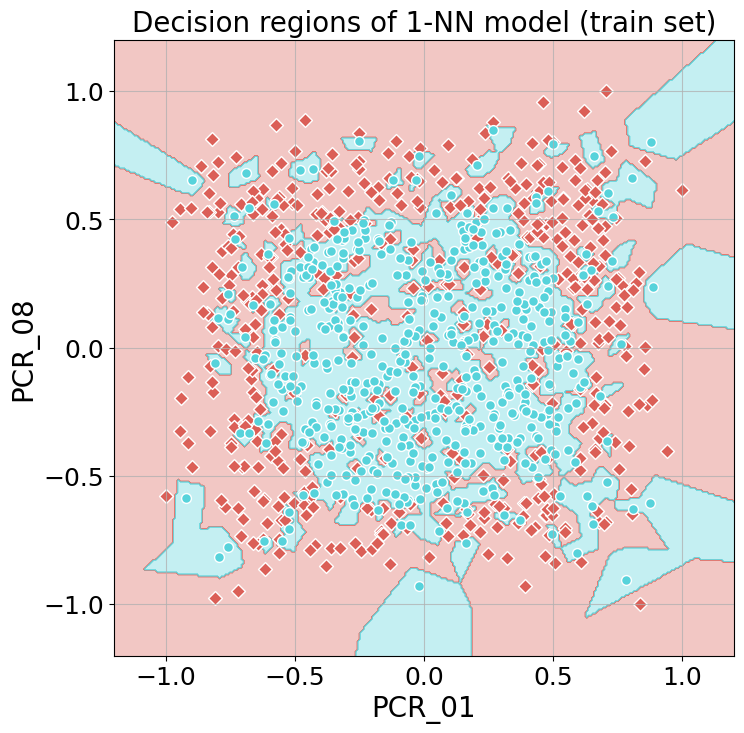

Accuracy on train set:  1.0


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


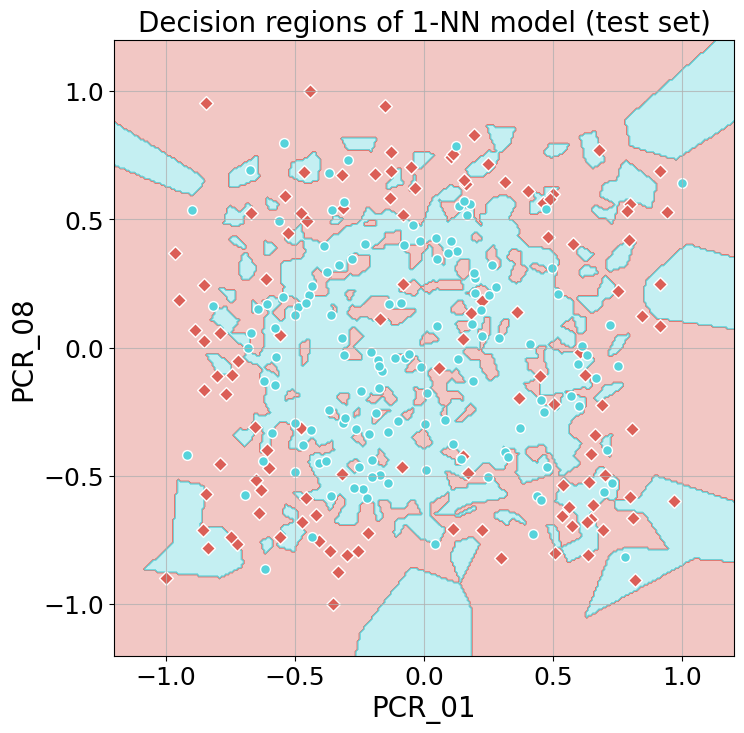

Accuracy on test set:  0.68


In [45]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=1)
knn_classifier.fit(train_pcr1_pcr8, train_spread)

# Results on train set
visualize_clf(knn_classifier,train_pcr1_pcr8, train_spread,"Decision regions of 1-NN model (train set)", 'PCR_01', "PCR_08")
accuracy = knn_classifier.score(train_pcr1_pcr8, train_spread)

print("Accuracy on train set: ", accuracy)

# Results on test set
visualize_clf(knn_classifier,test_pcr1_pcr8, test_spread,"Decision regions of 1-NN model (test set)", 'PCR_01', "PCR_08")
accuracy = knn_classifier.score(test_pcr1_pcr8, test_spread)

print("Accuracy on test set: ", accuracy)

## Q2

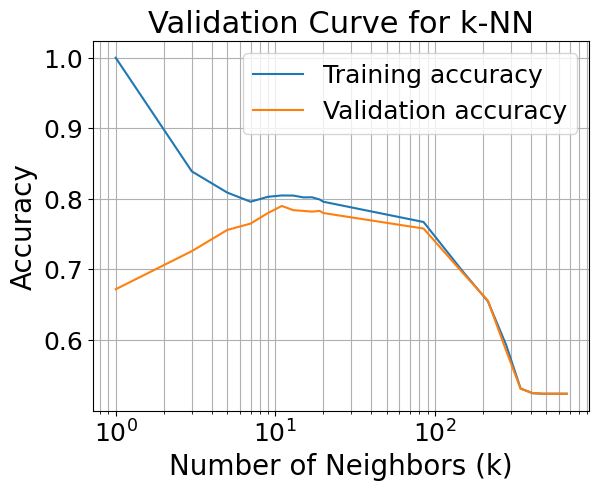

In [46]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier

# Create a range of k values
k_values = list(range(1, 20, 2)) + list(range(20, 695, 65))

# For each k, lists to store mean scores
validation_scores = []
train_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Perform cross-validation
    cv_results = cross_validate(knn, train_pcr1_pcr8, train_spread, cv=8, return_train_score=True)
    # Calculate mean and append mean accuracies to the lists
    train_scores.append(np.mean(cv_results['train_score']))
    validation_scores.append(np.mean(cv_results['test_score']))

plt.semilogx(k_values, train_scores, label='Training accuracy')
plt.semilogx(k_values, validation_scores, label='Validation accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Validation Curve for k-NN')
plt.legend()
plt.grid(True, which="both")
plt.show()

In [47]:
# Finding the k that gave us the highest validation accuracy
highest_validation_index = validation_scores.index(max(validation_scores))
best_k_validation = k_values[highest_validation_index]
print(f"highest validation accuracy is given from k-value: {best_k_validation}")

# Calculate its accuracy on train data
train_data_accuracy = train_scores[highest_validation_index]
validation_data_accuracy = validation_scores[highest_validation_index]

print(f"Average accuracy on train data: {train_data_accuracy}")
print(f"Average accuracy on validation data: {validation_data_accuracy}")

highest validation accuracy is given from k-value: 11
Average accuracy on train data: 0.8048571428571428
Average accuracy on validation data: 0.79


#Q3

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


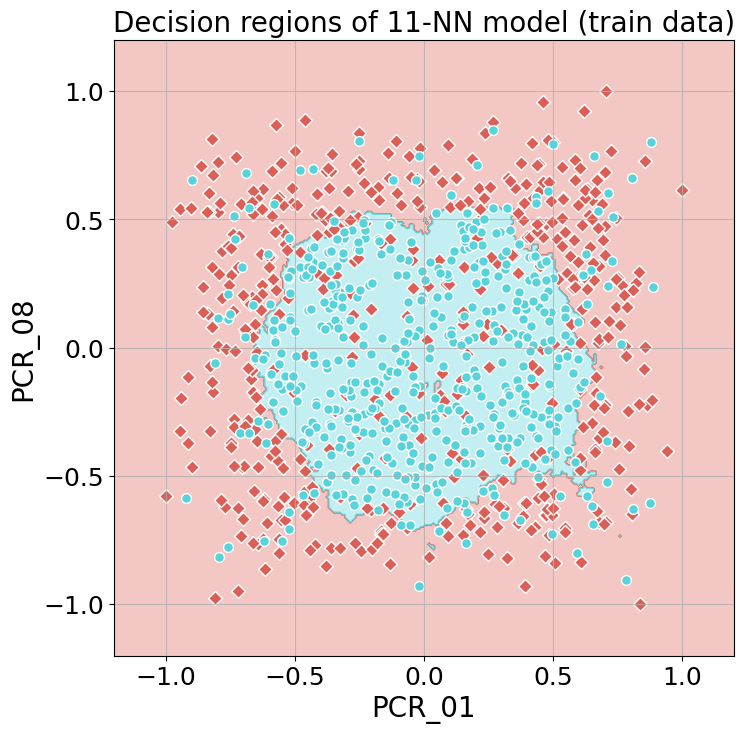

Accuracy on train set:  0.805


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


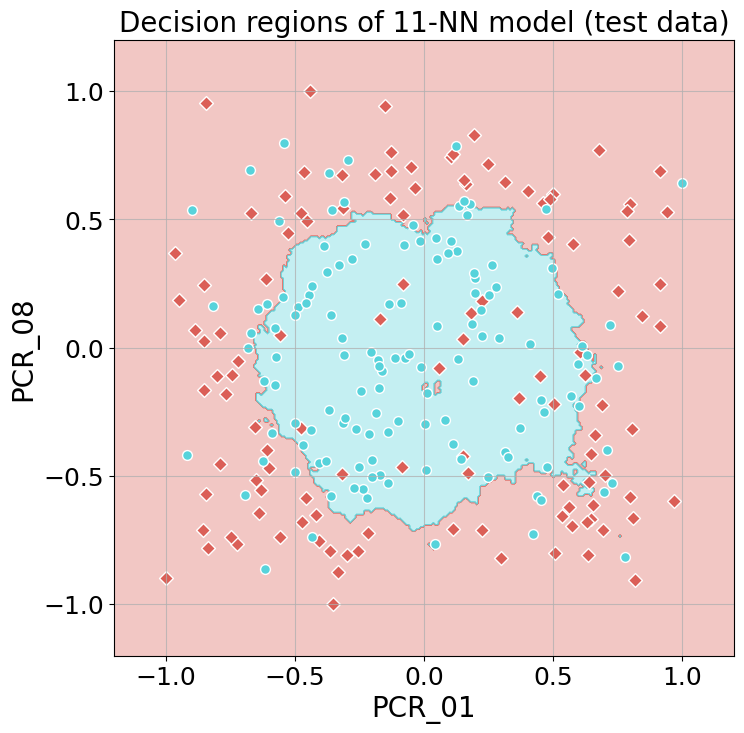

Accuracy on test set:  0.772


In [48]:
# We found k = 11 to be the best k
knn_11_classifier = KNeighborsClassifier(n_neighbors=11)
knn_11_classifier.fit(train_pcr1_pcr8, train_spread)

# Train set decision regions
visualize_clf(knn_11_classifier, train_pcr1_pcr8, train_spread, "Decision regions of 11-NN model (train data)", "PCR_01", "PCR_08")
accuracy = knn_11_classifier.score(train_pcr1_pcr8, train_spread)
print("Accuracy on train set: ", accuracy)

# Test set decision regions
visualize_clf(knn_11_classifier,test_pcr1_pcr8, test_spread,"Decision regions of 11-NN model (test data)", "PCR_01", "PCR_08")
accuracy = knn_11_classifier.score(test_pcr1_pcr8, test_spread)
print("Accuracy on test set: ", accuracy)

# Part 2

#Q5

In [49]:
X_train = train_df[['PCR_04','PCR_06','SpecialProperty']]
y_train = train_df['risk']

X_test = test_df[['PCR_04','PCR_06','SpecialProperty']]
y_test = test_df['risk']

Training Accuracy: 0.681


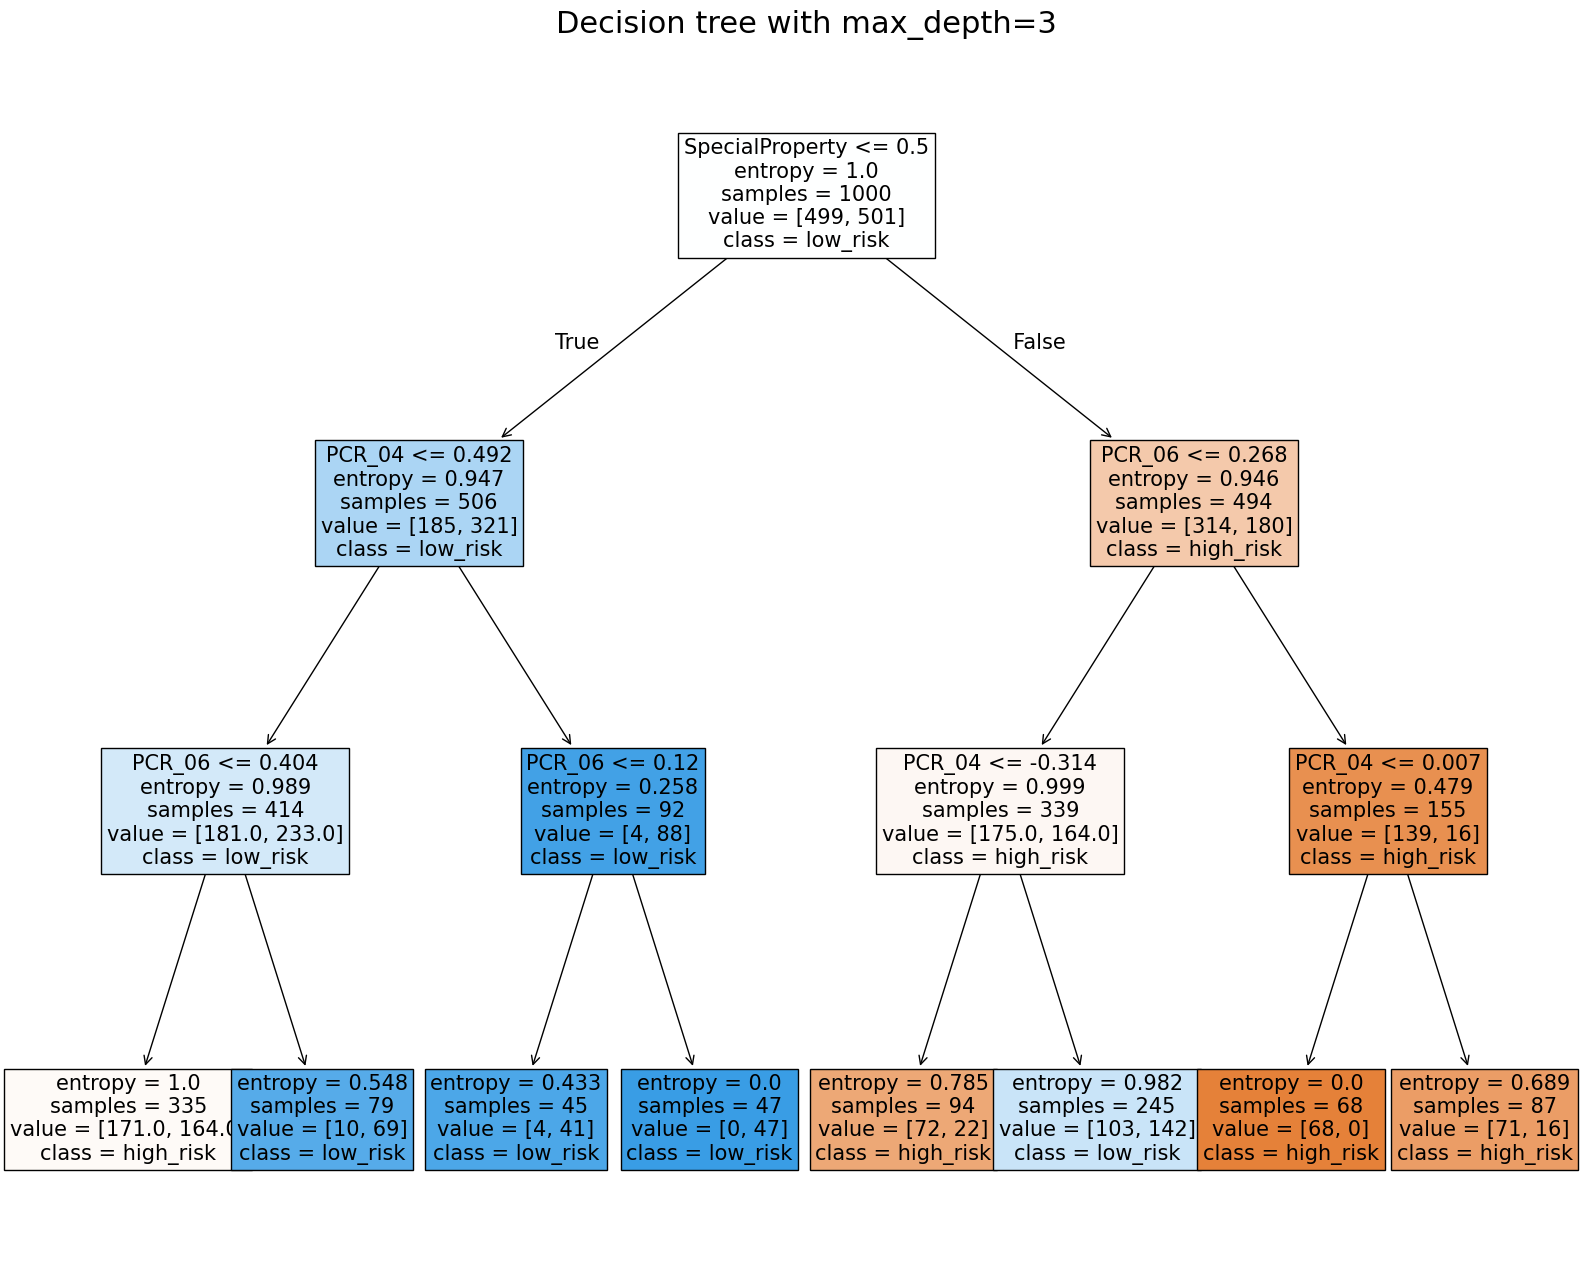

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

# DecisionTreeClassifier with ID3 and max_depth=3
dt_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=3)
dt_classifier.fit(X_train,y_train)

# Predict the labels
y_prediction = dt_classifier.predict(X_train)

# Calculate training accuracy
training_accuracy = accuracy_score(y_train, y_prediction)
print(f"Training Accuracy: {training_accuracy}")

# Plot decision tree
plt.figure(figsize=(20, 16))
plot_tree(dt_classifier, filled=True, feature_names=X_train.columns, class_names=['high_risk', 'low_risk'], fontsize = 15)
plt.title('Decision tree with max_depth=3', fontsize=22)
plt.show()

#Q6

the best parameters are {'max_depth': 8, 'min_samples_split': 12}


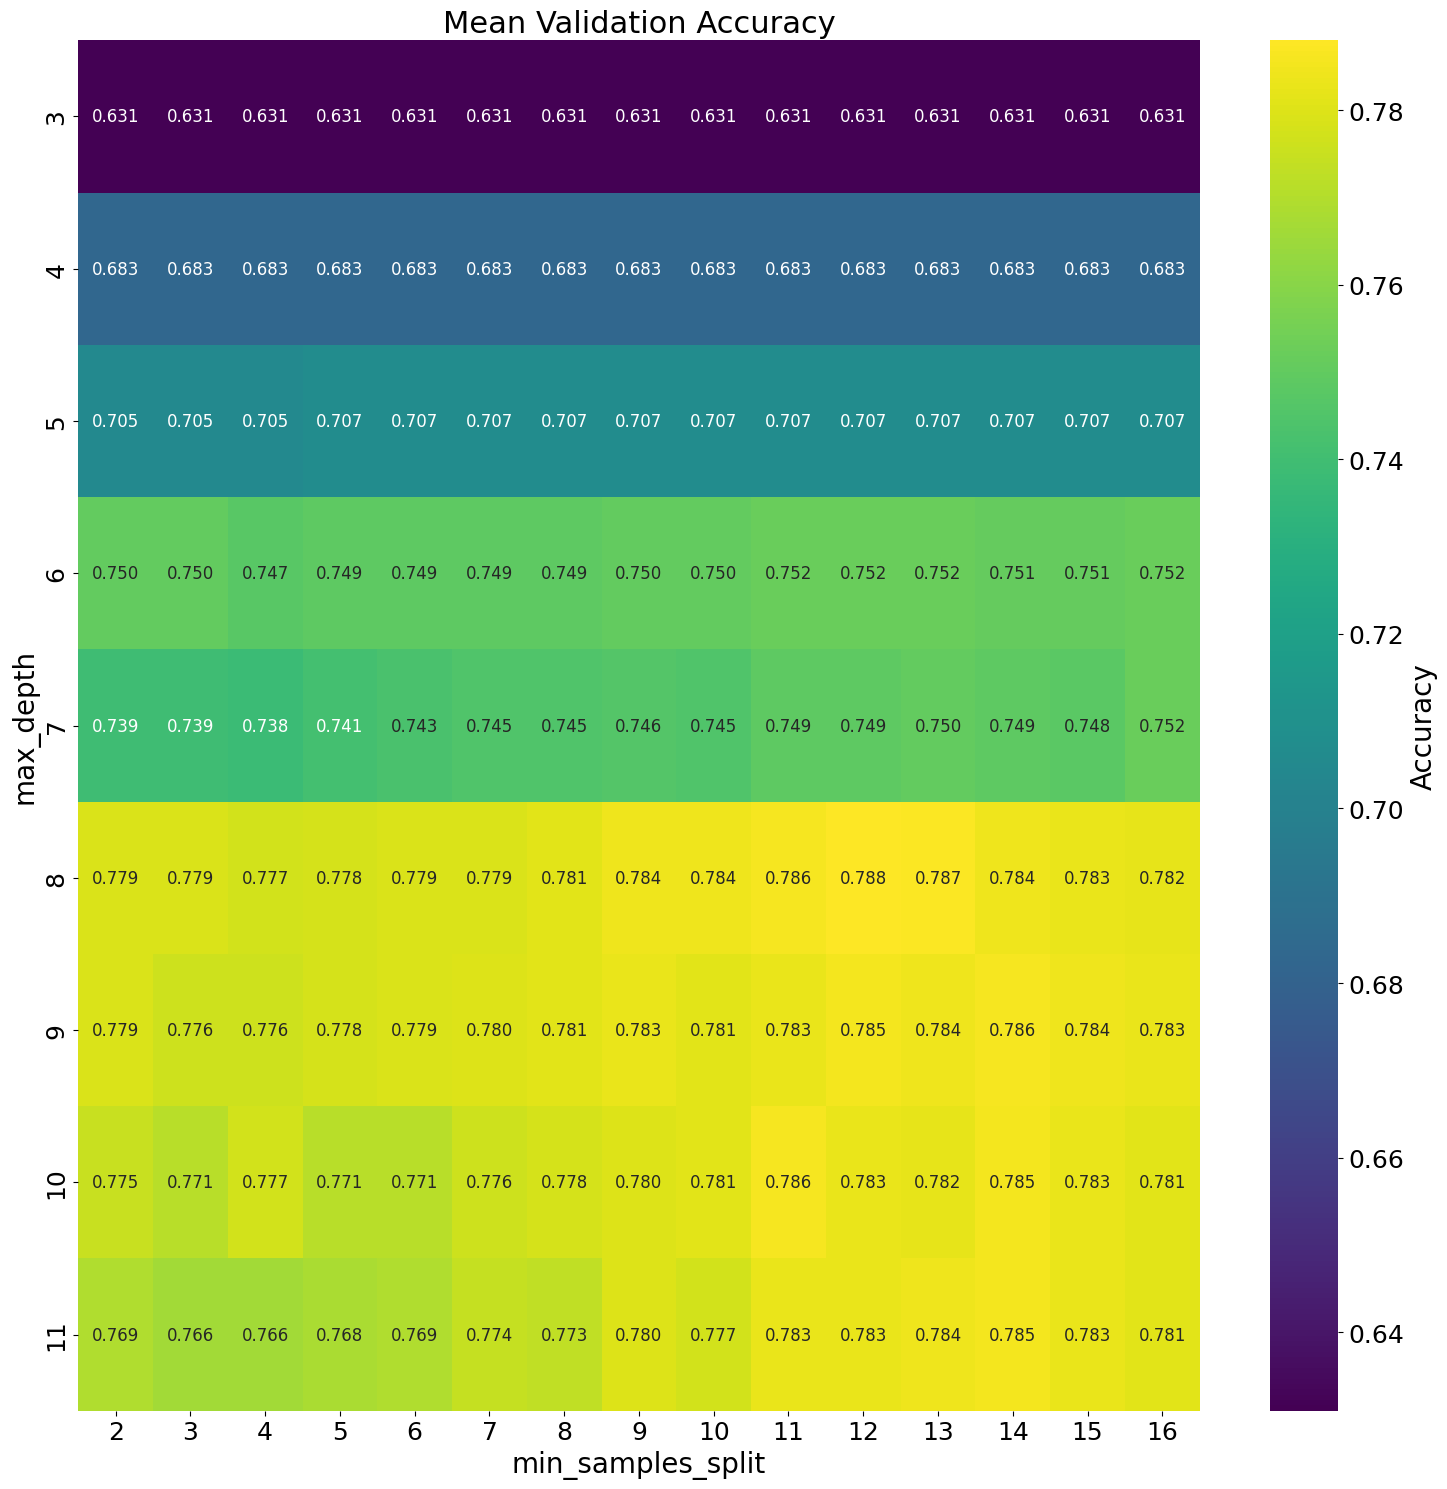

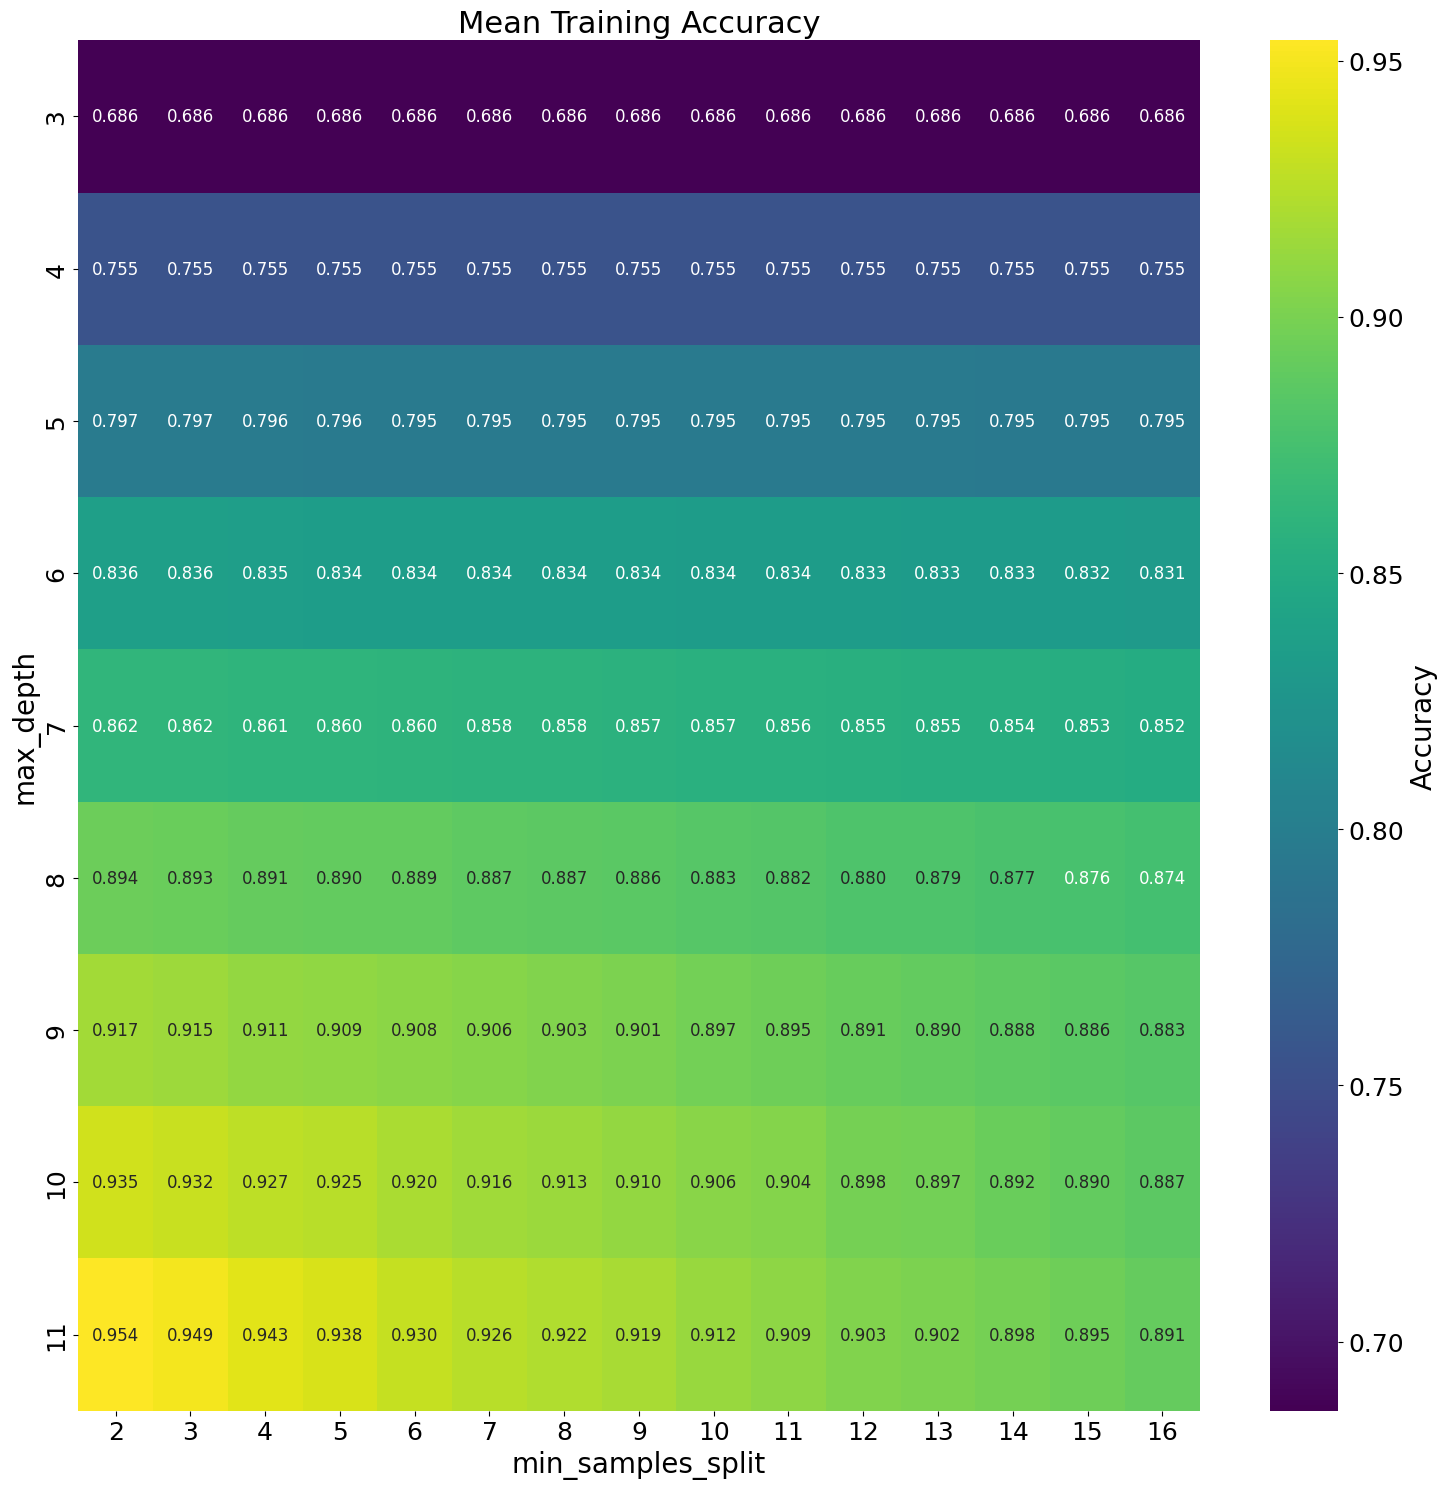

In [51]:
from sklearn.model_selection import GridSearchCV
import seaborn

tree_classifier = DecisionTreeClassifier(criterion='entropy',random_state=98)
parameters = {'max_depth': np.arange(3, 12), 'min_samples_split':np.arange(2, 17, 1)}
grid_search = GridSearchCV(tree_classifier, parameters, cv=5, scoring='accuracy', return_train_score=True)
grid_search.fit(X_train, y_train)

# Finding best parameters
best_params = grid_search.best_params_
print("the best parameters are", best_params)

# Move to a DataFrame from grid_search.cv_results_
results = pd.DataFrame(grid_search.cv_results_)

# Reshape the mean training and validation scores into matrices and pivot the DataFrame for mean training scores & mean validation scores
train_matrix = results.pivot(index='param_max_depth', columns='param_min_samples_split', values='mean_train_score')
validation_matrix = results.pivot(index='param_max_depth', columns='param_min_samples_split', values='mean_test_score')

# Validation set accuracy heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(validation_matrix, annot=True, cmap="viridis", fmt=".3f", cbar_kws={'label': 'Accuracy'}, annot_kws={"size": 12})
plt.title('Mean Validation Accuracy')
plt.xlabel('min_samples_split')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

# Training set accuracy heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(train_matrix, annot=True, cmap="viridis", fmt=".3f", cbar_kws={'label': 'Accuracy'}, annot_kws={"size": 12})
plt.title('Mean Training Accuracy')
plt.xlabel('min_samples_split')
plt.ylabel('max_depth')
plt.tight_layout()
plt.show()

#Q8

In [52]:
# DecisionTreeClassifier with ID3 and max_depth=8
new_tree_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=8 ,min_samples_leaf = 12)
new_tree_classifier.fit(X_train, y_train)

# Predict the labels
y_test_prediction = new_tree_classifier.predict(X_test)

# Calculate test accuracy
test_accuracy = accuracy_score(y_test, y_test_prediction)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.824


# Part 3

In [15]:
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class SoftSVM(BaseEstimator, ClassifierMixin):
    """
    Custom C-Support Vector Classification.
    """
    def __init__(self, C: float, lr: float = 1e-5, batch_size = 32):
        """
        Initialize an instance of this class.
        ** Do not edit this method **

        :param C: inverse strength of regularization. Must be strictly positive.
        :param lr: the SGD learning rate (step size)
        """
        self.C = C
        self.lr = lr
        self.batch_size = batch_size
        self.w = None
        self.b = 0.0

    # Initialize a random weight vector
    def init_solution(self, n_features: int):
        """
        Randomize an initial solution (weight vector)
        ** Do not edit this method **

        :param n_features:
        """
        self.w = np.random.randn(n_features)
        self.b = 0.0

    @staticmethod
    def loss(w, b: float, C: float, X, y):
        """
        Compute the SVM objective loss.

        :param w: weight vector for linear classification; array of shape (n_features,)
        :param b: bias scalar for linear classification
        :param C: inverse strength of regularization. Must be strictly positive.
        :param X: samples for loss computation; array of shape (n_samples, n_features)
        :param y: targets for loss computation; array of shape (n_samples,)
        :return: the Soft SVM objective loss (float scalar)
        """
        # Calculating the hinge function for each data point
        margins = (X.dot(w) + b).reshape(-1, 1)
        hinge_inputs = np.multiply(margins, y.reshape(-1, 1))
        hinge_outputs = np.maximum(0, 1 - hinge_inputs)

        # Norm W
        norm = np.linalg.norm(w)

        # Constructing the loss function
        loss = norm**2 + np.sum(hinge_outputs)*C

        return loss

    @staticmethod
    def subgradient(w, b: float, C: float, X, y):
        """
        Compute the (analytical) SVM objective sub-gradient.

        :param w: weight vector for linear classification; array of shape (n_features,)
        :param b: bias scalar for linear classification
        :param C: inverse strength of regularization. Must be strictly positive.
        :param X: samples for loss computation; array of shape (n_samples, n_features)
        :param y: targets for loss computation; array of shape (n_samples,)
        :return: a tuple with (the gradient of the weights, the gradient of the bias)
        """
        # calculating vector of f(yi(wTxi+b))yi
        # will be used both in g_w and g_b
        margins = (X.dot(w) + b).reshape(-1, 1)
        margins_y = np.multiply(margins, y.reshape(-1,1))
        f_margins_y = np.multiply(np.where(margins_y < 1,-1,0), y.reshape(-1,1))

        g_w = w*2 + np.sum(np.multiply(X, f_margins_y), axis = 0) * C
        g_b = np.sum(f_margins_y)*C

        return g_w, g_b

    def fit_with_logs(self, X, y, max_iter: int = 2000, keep_losses: bool = True):
        """
        Fit the model according to the given training data.

        :param X: training samples; array of shape (n_samples, n_features)
        :param y: training targets (+1 and -1); array of shape (n_samples,)
        :param max_iter: number of SGD iterations
        :param keep_losses:
        :return: the training losses and accuracies during training
        """
        # Initialize learned parameters
        self.init_solution(X.shape[1])

        losses = []
        accuracies = []

        if keep_losses:
            losses.append(self.loss(self.w, self.b, self.C, X, y))
            accuracies.append(self.score(X, y))

        permutation = np.random.permutation(len(y))
        X = X[permutation, :]
        y = y[permutation]

        # Iterate over batches
        for iter in range(0, max_iter):
            start_idx = (iter * self.batch_size) % X.shape[0]
            end_idx = min(X.shape[0], start_idx + self.batch_size)
            batch_X = X[start_idx:end_idx, :]
            batch_y = y[start_idx:end_idx]

            g_w, g_b = self.subgradient(self.w, self.b, self.C, batch_X, batch_y)

            # Perform a (sub)gradient step
            self.w = self.w - self.lr*g_w
            self.b = self.b - self.lr*g_b

            if keep_losses:
                losses.append(self.loss(self.w, self.b, self.C, X, y))
                accuracies.append(self.score(X, y))

        return losses, accuracies

    def fit(self, X, y, max_iter: int = 2000):
        """
        Fit the model according to the given training data.
        ** Do not edit this method **

        :param X: training samples; array of shape (n_samples, n_features)
        :param y: training targets (+1 and -1); array of shape (n_samples,)
        :param max_iter: number of SGD iterations
        """
        self.fit_with_logs(X, y, max_iter=max_iter, keep_losses=False)

        return self

    def predict(self, X):
        """
        Perform classification on samples in X.

        :param X: samples for prediction; array of shape (n_samples, n_features)
        :return: Predicted class labels for samples in X; array of shape (n_samples,)
                 NOTE: the labels must be either +1 or -1
        """

        y_pred = np.sign(X.dot(self.w)+self.b)

        return y_pred


In [16]:
def numerical_subgradient(w, b, C, X, y, delta=1e-4):
    w_ = w.copy()
    g_w = np.zeros_like(w_)
    orig_objective = SoftSVM.loss(w_, b, C, X, y)
    for i in range(g_w.shape[0]):
        w_[i] += delta
        perturbed_objective = SoftSVM.loss(w_, b, C, X, y)
        w_[i] -= delta
        g_w[i] = (perturbed_objective - orig_objective) / delta

    g_b = (SoftSVM.loss(w_, b + delta, C, X, y) - orig_objective) / delta
    return g_w, g_b



def compare_gradients(X, y, deltas, C=1, REPEATS=100, figsize=(10, 6)):
    residual_means = []

    for delta in deltas:
        residuals = []

        for _ in range(REPEATS):
            # Randomize vectors in which the gradient is computed
            w = np.random.randn(X.shape[1])
            b = np.random.randn(1)

            # Compute the two types of gradients
            analytic_grad = SoftSVM.subgradient(w, b, C, X, y)[0]
            numeric_grad = numerical_subgradient(w, b, C, X, y, delta=delta)[0]

            residual = np.linalg.norm(numeric_grad - analytic_grad)
            residuals.append(residual)

        residual_means.append(np.mean(residuals))

    plt.figure(figsize=figsize)
    plt.title('Residuals of analytical and numerical gradients', fontsize=22)
    plt.plot(deltas, residual_means, linewidth=3)
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('$\delta$', fontsize=18)
    plt.ylabel(r'$\left\Vert \nabla_{w}p_{C}\left(w,b\right) - u_{\delta} \left(w,b\right)\right\Vert$', fontsize=18)

    plt.grid(alpha=0.5)
    plt.show()


## Q9

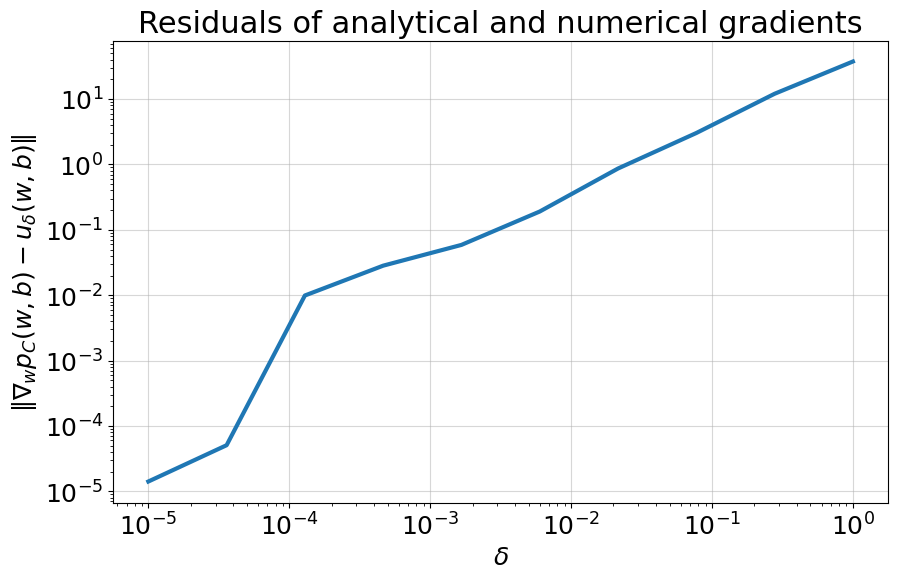

In [17]:
X_train = train_df[['PCR_01', 'PCR_08']].to_numpy()
y_train = train_df['spread'].to_numpy()

# Will be used later
X_test = test_df[['PCR_01', 'PCR_08']].to_numpy()
y_test = test_df['spread'].to_numpy()

compare_gradients(X_train, y_train, deltas=np.logspace(-5, 0, 10))

## Task

## Q11

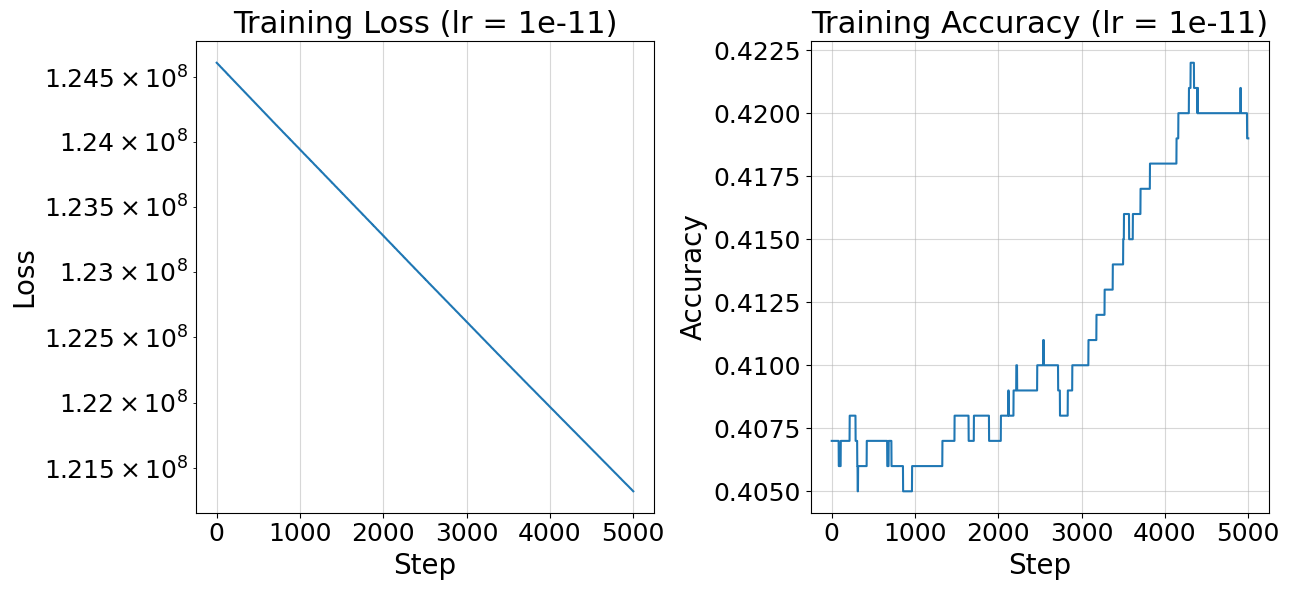

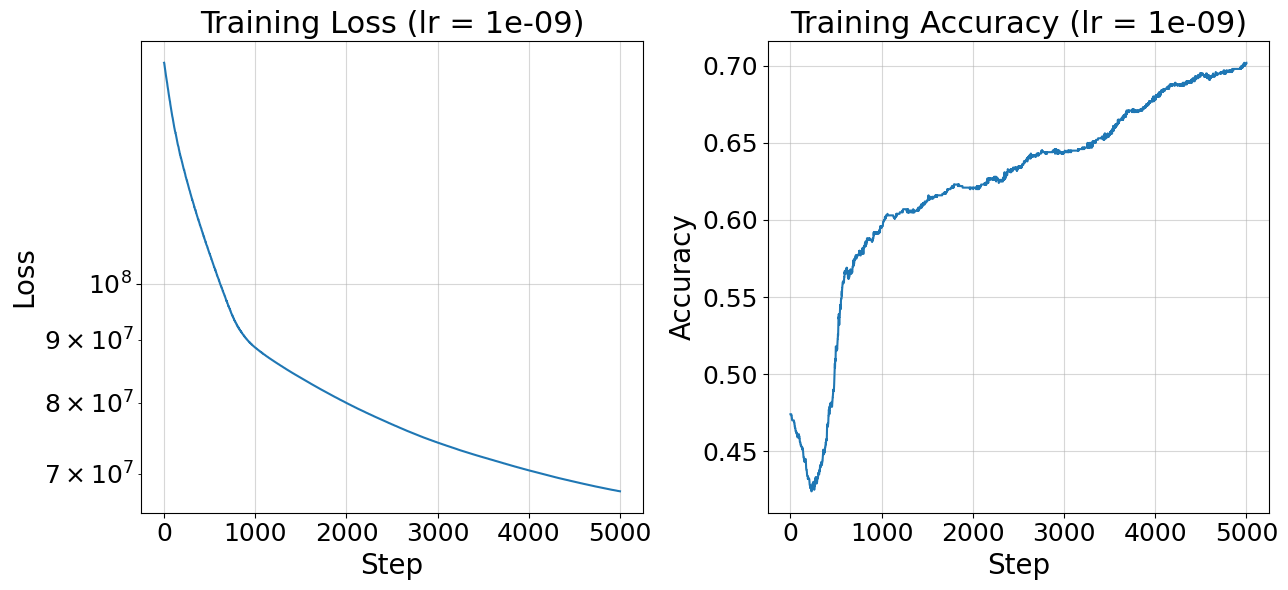

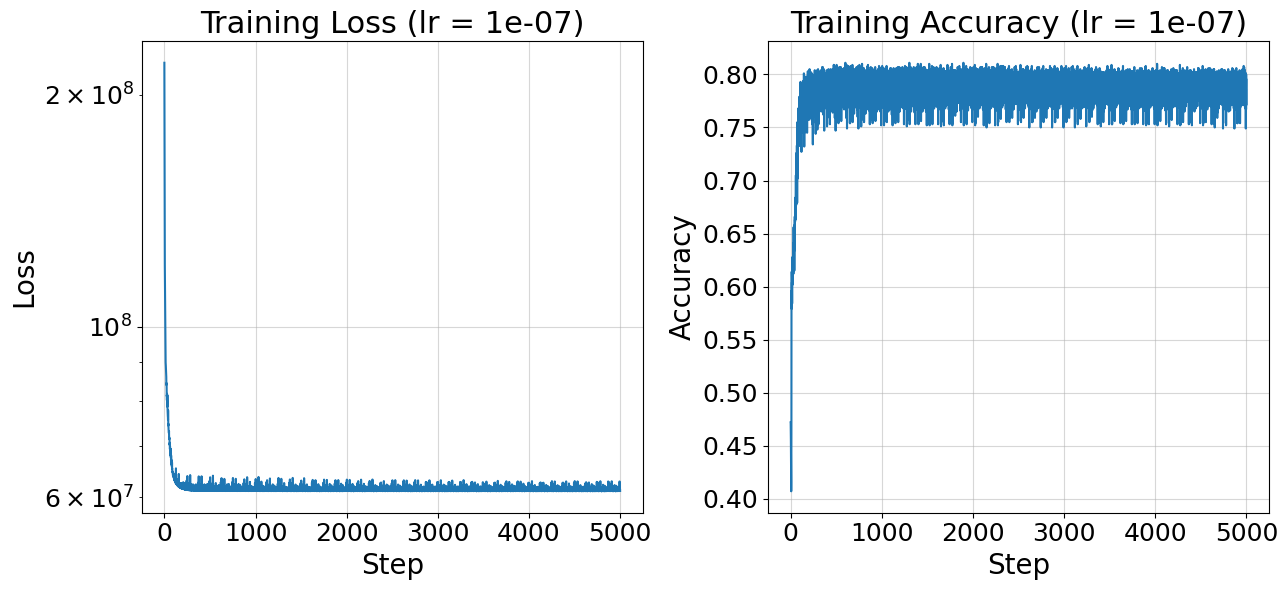

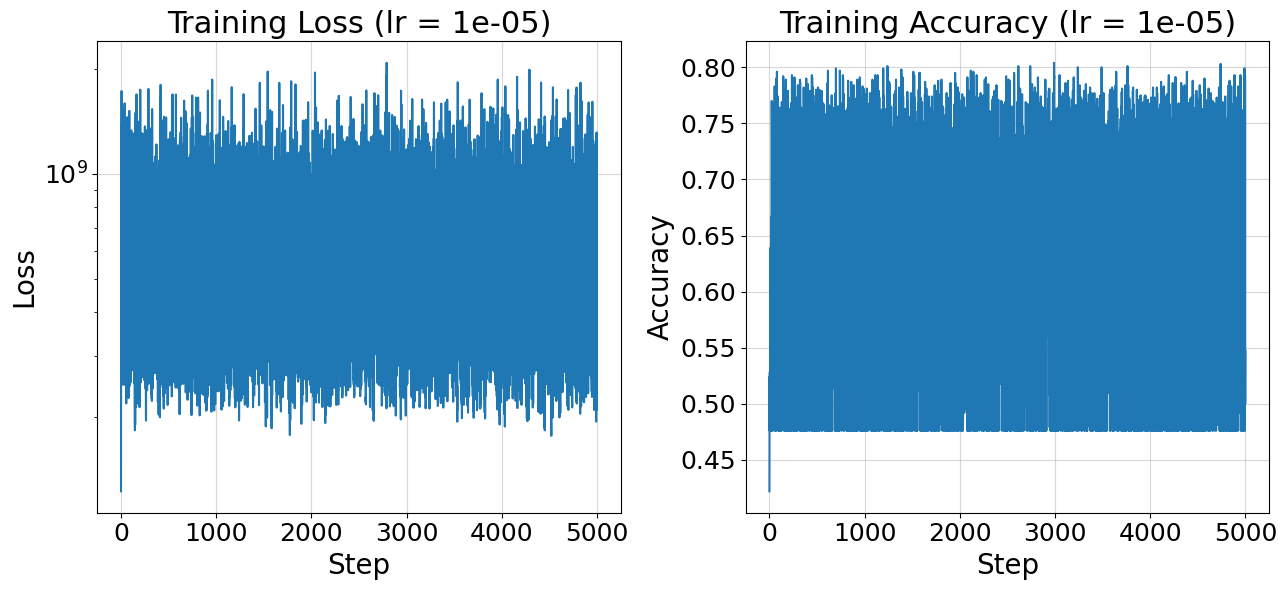

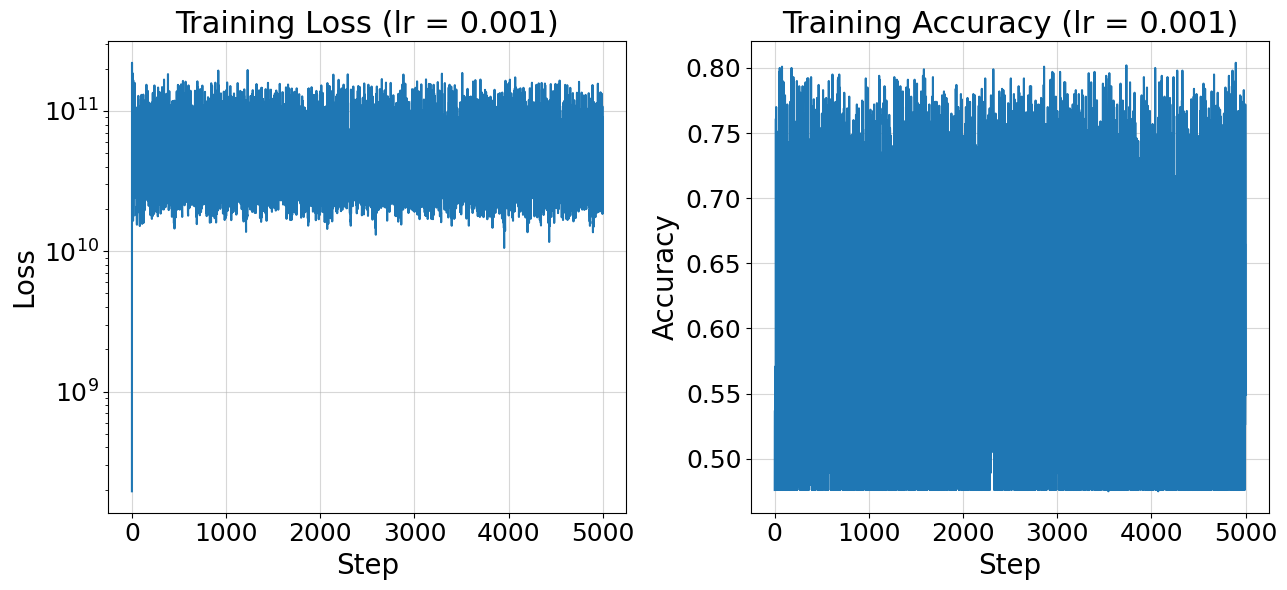

In [19]:
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler

C=1e5

for lr in np.logspace(-11, -3, 5):
  clf = SoftSVM(C=C, lr=lr)
  X_train_poly = PolynomialFeatures(degree=3,).fit_transform(X_train)
  X_train_poly = MinMaxScaler(feature_range=(-1,1)).fit_transform(X_train_poly)
  losses, accuracies = clf.fit_with_logs(X_train_poly, y_train, max_iter=5000)
  plt.figure(figsize=(13, 6))
  plt.subplot(121), plt.grid(alpha=0.5), plt.title (f"Training Loss (lr = {lr})")
  plt.semilogy(losses), plt.xlabel("Step"), plt.ylabel("Loss")
  plt.subplot(122), plt.grid(alpha=0.5), plt.title (f"Training Accuracy (lr = {lr})")
  plt.plot(accuracies), plt.xlabel("Step"), plt.ylabel("Accuracy")
  plt.tight_layout()
  plt.show()

## Q12

In [24]:
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.pipeline import Pipeline

# Creating Pipeline
svm_clf = Pipeline([('feature_mapping', PolynomialFeatures(degree=3)),
('scaler', MinMaxScaler()),
('SVM', SoftSVM(C=1e5, lr=1e-7))])
svm_clf.fit(X_train, y_train)

Pipeline(steps=[('feature_mapping', PolynomialFeatures(degree=3)),
                ('scaler', MinMaxScaler()),
                ('SVM', SoftSVM(C=100000.0, lr=1e-07))])

/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


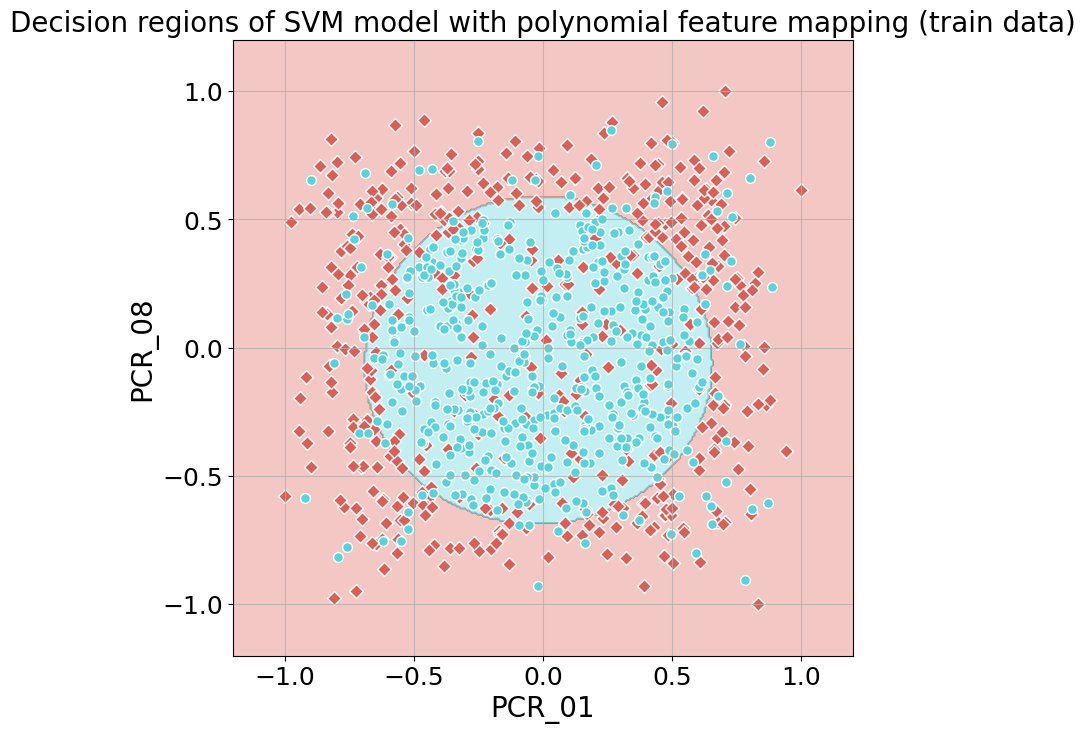

/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


0.78


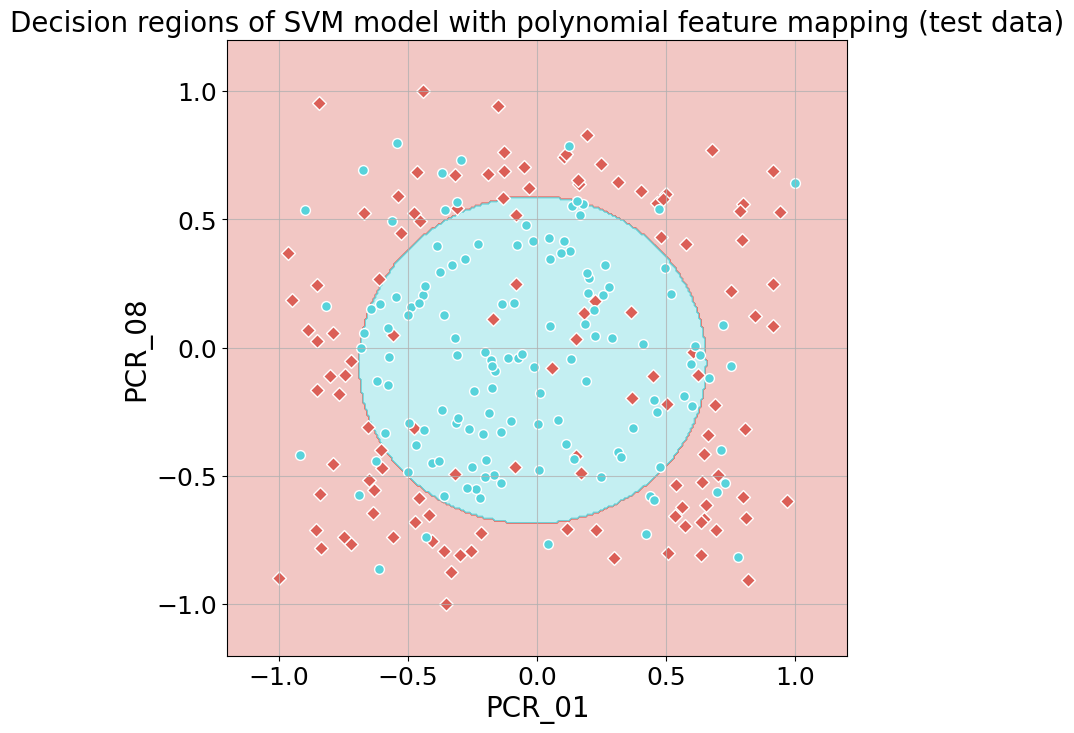

0.808


/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [25]:
# Train set decision regions
visualize_clf(svm_clf, X_train, y_train, "Decision regions of SVM model with polynomial feature mapping (train data)", "PCR_01", "PCR_08")
print(svm_clf.score(X_train, y_train))

# Test set decision regions
visualize_clf(svm_clf, X_test, y_test, "Decision regions of SVM model with polynomial feature mapping (test data)", "PCR_01", "PCR_08")
print(svm_clf.score(X_test, y_test))

## Q14

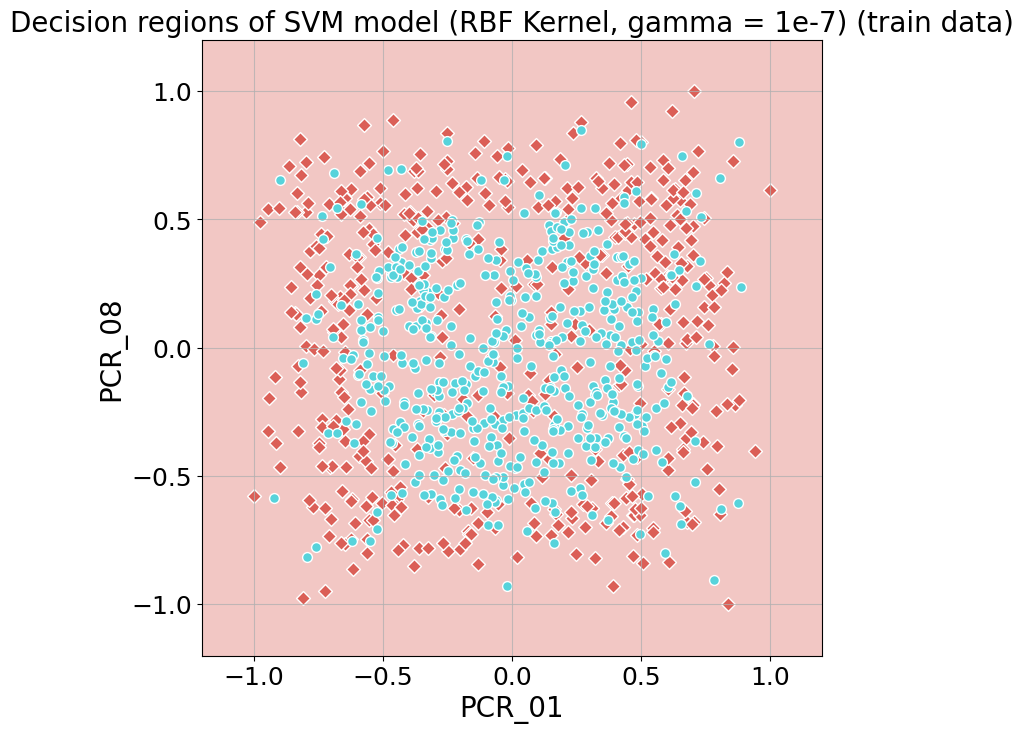

Training Accuracy: 0.524


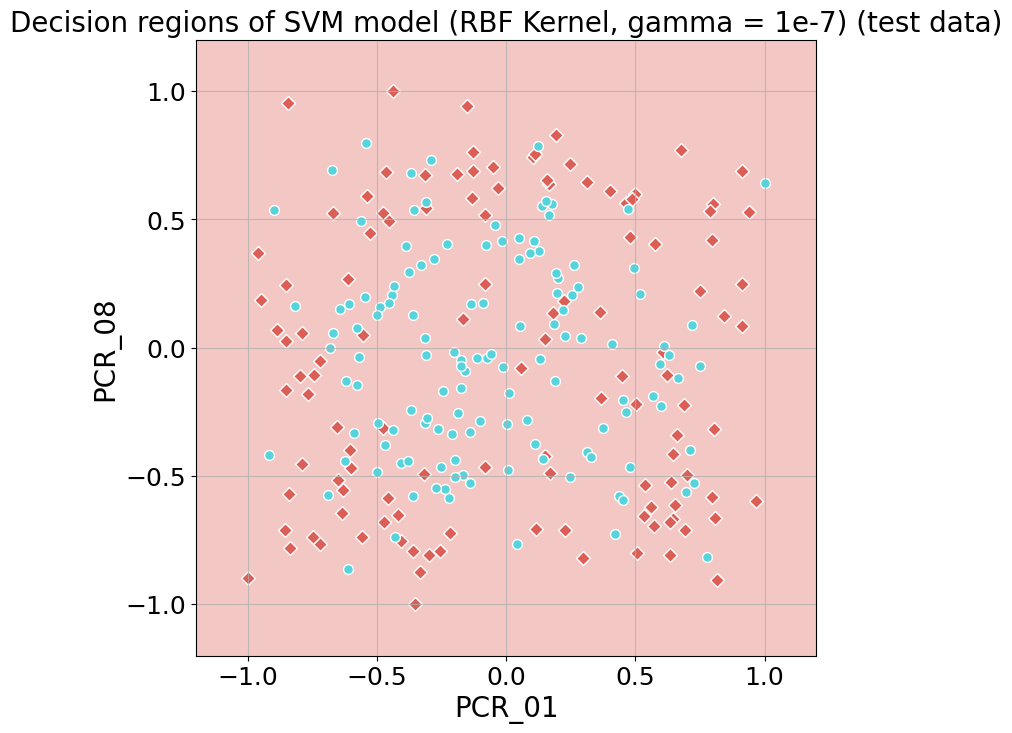

Test Accuracy: 0.528


In [29]:
from sklearn.svm import SVC

svm_clf = SVC(kernel="rbf", C=1, gamma=1e-7)
svm_clf.fit(X_train, y_train)

train_accuracy = svm_clf.score(X_train, y_train)
test_accuracy = svm_clf.score(X_test, y_test)

visualize_clf(svm_clf, X_train, y_train, "Decision regions of SVM model (RBF Kernel, gamma = 1e-7) (train data)", "PCR_01", "PCR_08")
print(f"Training Accuracy: {train_accuracy}")

visualize_clf(svm_clf, X_test, y_test, "Decision regions of SVM model (RBF Kernel, gamma = 1e-7) (test data)", "PCR_01", "PCR_08")
print(f"Test Accuracy: {test_accuracy}")

## Q15

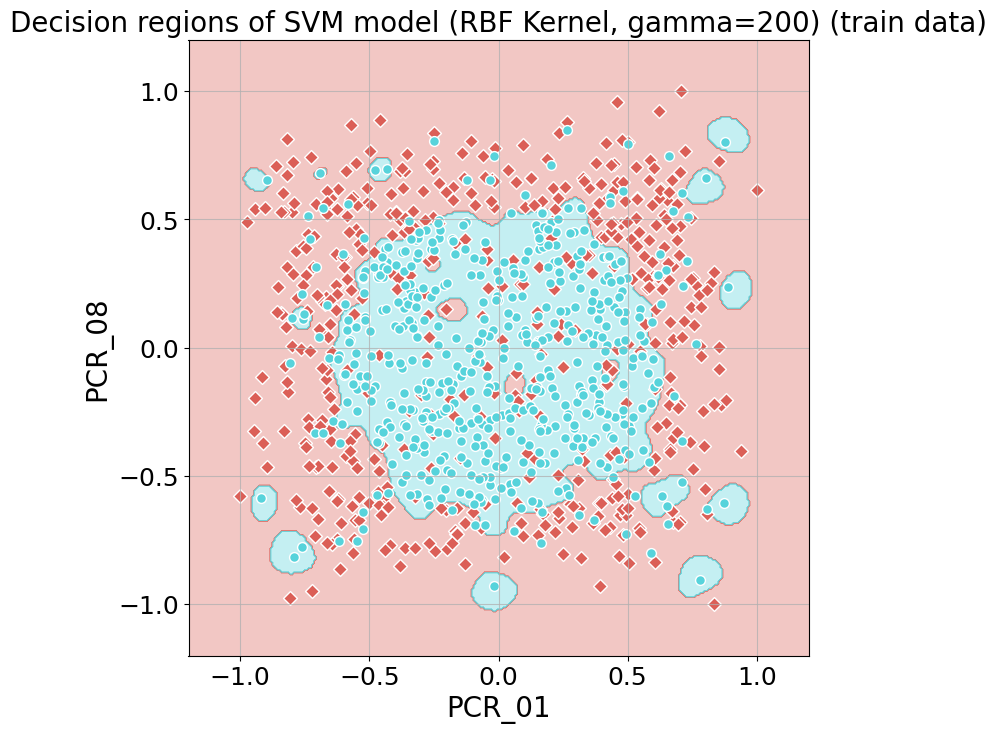

Training Accuracy: 0.845


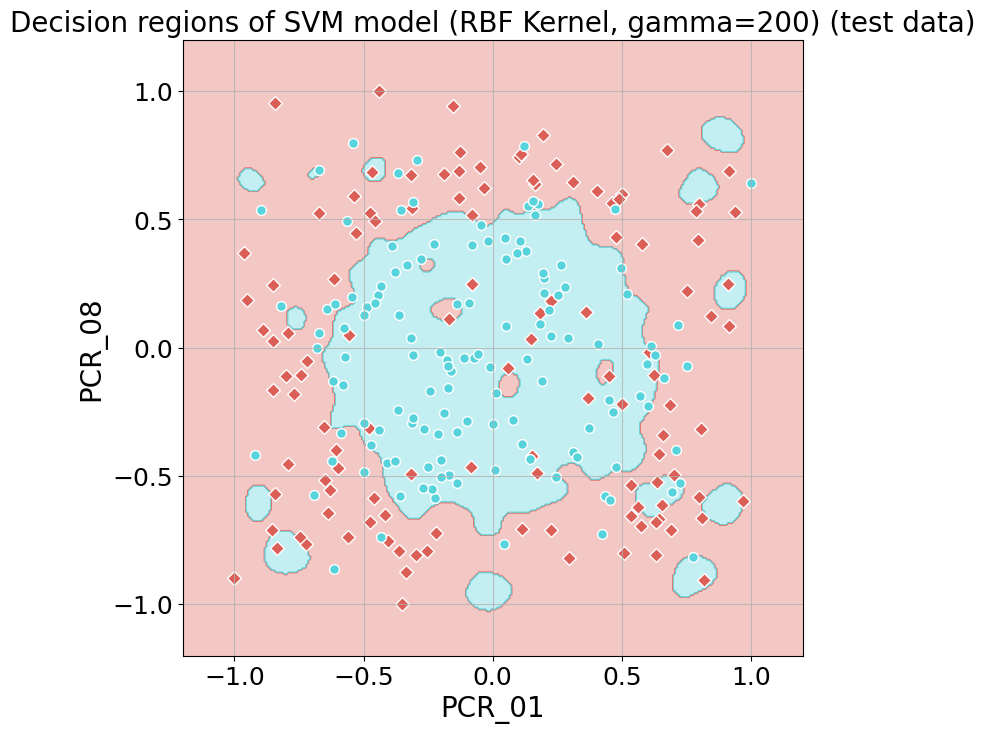

Test Accuracy: 0.764


In [30]:
from sklearn.svm import SVC

svm_clf = SVC(kernel="rbf", C=1, gamma=200)
svm_clf.fit(X_train, y_train)

train_accuracy = svm_clf.score(X_train, y_train)
test_accuracy = svm_clf.score(X_test, y_test)

visualize_clf(svm_clf, X_train, y_train, "Decision regions of SVM model (RBF Kernel, gamma=200) (train data)", "PCR_01", "PCR_08")
print(f"Training Accuracy: {train_accuracy}")

visualize_clf(svm_clf, X_test, y_test, "Decision regions of SVM model (RBF Kernel, gamma=200) (test data)", "PCR_01", "PCR_08")
print(f"Test Accuracy: {test_accuracy}")

## Q16

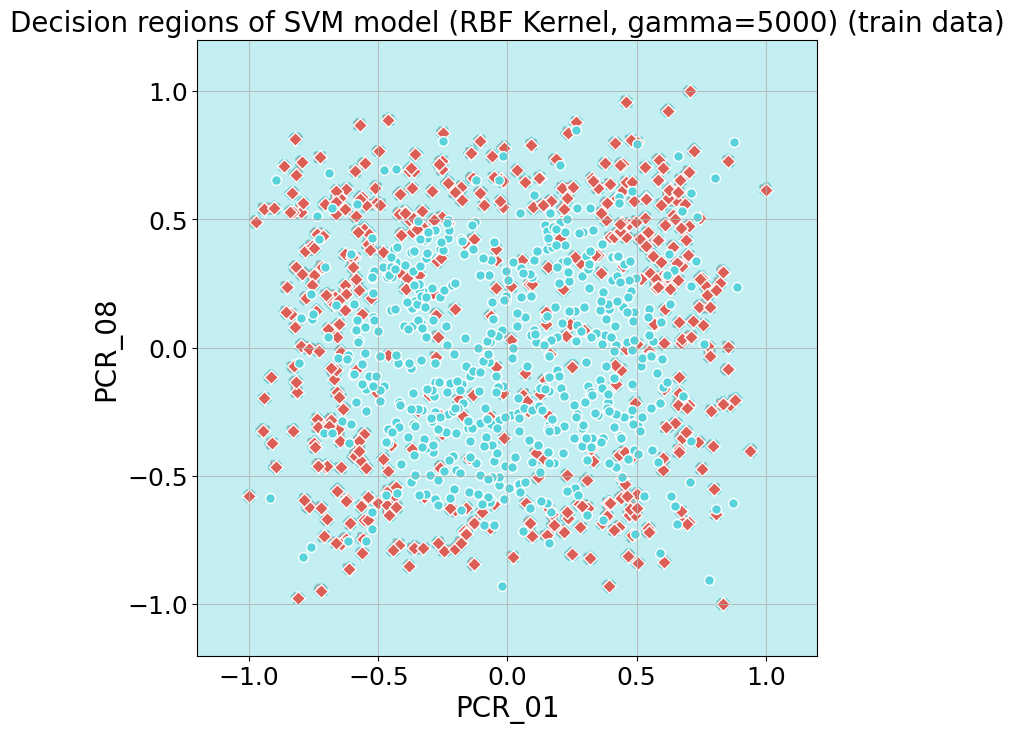

Training Accuracy: 0.995


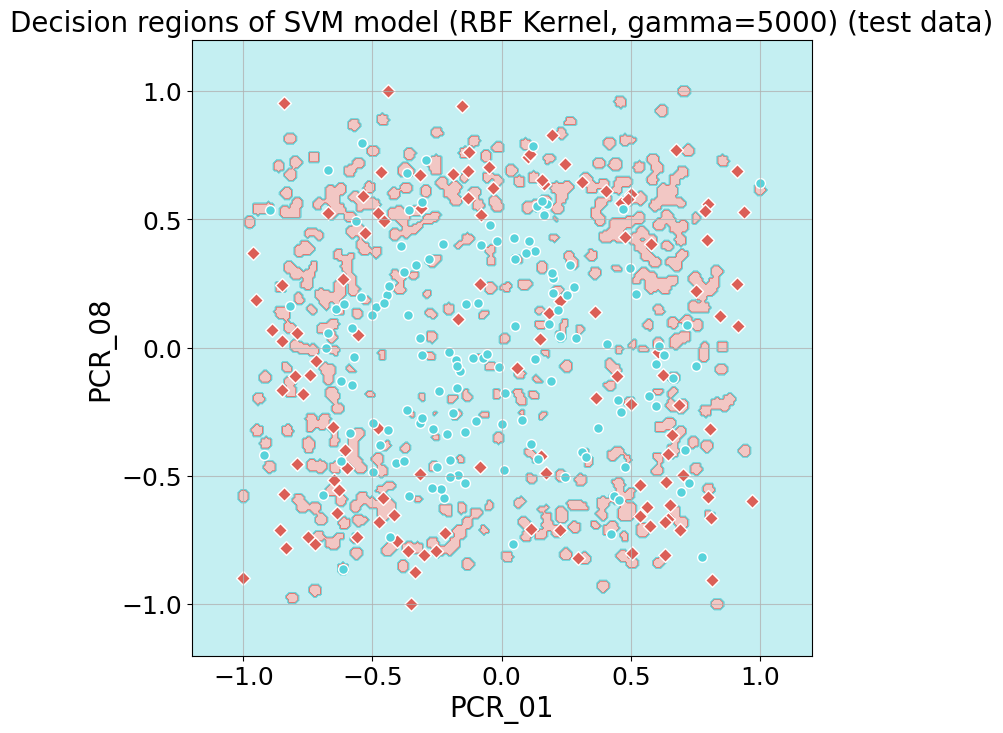

Test Accuracy: 0.516


In [31]:
from sklearn.svm import SVC

svm_clf = SVC(kernel="rbf", C=1, gamma=5000)
svm_clf.fit(X_train, y_train)

train_accuracy = svm_clf.score(X_train, y_train)
test_accuracy = svm_clf.score(X_test, y_test)

visualize_clf(svm_clf, X_train, y_train, "Decision regions of SVM model (RBF Kernel, gamma=5000) (train data)", "PCR_01", "PCR_08")
print(f"Training Accuracy: {train_accuracy}")

visualize_clf(svm_clf, X_test, y_test, "Decision regions of SVM model (RBF Kernel, gamma=5000) (test data)", "PCR_01", "PCR_08")
print(f"Test Accuracy: {test_accuracy}")